In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el Dataset
products = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_products_dataset.csv")
orders = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_orders_dataset.csv")
order_items = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_order_items_dataset.csv")
reviews = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_order_reviews_dataset.csv")
payments = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_order_payments_dataset.csv")
customers = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_customers_dataset.csv")
translation = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\product_category_name_translation.csv")

se priorizarán las tablas directamente relacionadas con el comportamiento transaccional, el catálogo de productos, las reseñas, los pagos y la información de clientes, complementadas con la tabla de traducción de categorías para mejorar la interpretación del negocio. Las tablas de vendedores y geolocalización serán consideradas de manera secundaria, dado que no son críticas para el MVP inicial del sistema de recomendación.

In [3]:
# Diccionario de Tablas
tablas = {
    "products": products,
    "orders": orders,
    "order_items": order_items,
    "reviews": reviews,
    "payments": payments,
    "customers": customers,
    "translation": translation
}

In [ ]:
# reconocimiento inicial de los datos
for nombre, df in tablas.items():
    print(f"\n--- {nombre.upper()} ---")
    print("Filas y columnas:", df.shape)
    print(df.head(3))


--- PRODUCTS ---
Filas y columnas: (32951, 9)
                         product_id product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5            perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                 artes   
2  96bd76ec8810374ed1b65e291975717f         esporte_lazer   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0               30.0               18.0              20.0  
2             154.0               18.0                9.0              15.0  

--- ORDERS ---
Filas y columnas: (99441, 8)
                           order_id                   

- La tabla products contiene información de 32,951 productos con 9 variables asociadas a sus características físicas y descriptivas.
Se identifican variables relevantes como la categoría del producto, longitud del nombre y descripción, cantidad de fotos y dimensiones físicas (peso, alto, ancho y largo).

    Esto permite inferir que el dataset no solo contiene información comercial, sino también atributos que pueden influir en la experiencia del cliente, como la calidad de la descripción o la presentación visual del producto.

- La tabla orders contiene 99,441 registros correspondientes a pedidos realizados por los clientes.
Cada registro representa una orden única, identificada mediante order_id, y asociada a un cliente mediante customer_id.

    Esta tabla es fundamental dentro del modelo de datos, ya que permite analizar el comportamiento de compra, frecuencia de pedidos y estados de las órdenes.

    Su volumen es considerablemente mayor que el de productos, lo que sugiere que múltiples pedidos pueden estar asociados a los mismos productos, lo cual será relevante al momento de realizar análisis relacionales.

In [ ]:
# Comprensión de variables
for nombre, df in tablas.items():
    print(f"\n--- COLUMNAS DE {nombre.upper()} ---")
    print(df.columns.tolist())


--- COLUMNAS DE PRODUCTS ---
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

--- COLUMNAS DE ORDERS ---
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- COLUMNAS DE ORDER_ITEMS ---
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--- COLUMNAS DE REVIEWS ---
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- COLUMNAS DE PAYMENTS ---
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--- COLUMNAS DE CUSTOMERS ---
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'custom

- La tabla products contiene variables relacionadas con las características físicas y descriptivas de los productos.
Se identifican atributos como categoría, longitud del nombre y descripción, cantidad de fotos y dimensiones físicas (peso, alto, ancho y largo). Estas variables son relevantes para analizar la calidad de la información del producto y su posible influencia en las decisiones de compra.

- La tabla orders contiene información transaccional de los pedidos, incluyendo su estado y diferentes marcas de tiempo asociadas al proceso logístico.
Se identifican variables clave como:

        fecha de compra,

        aprobación,

        envío,

        entrega al cliente,

        y fecha estimada de entrega.

- La tabla order_items representa el detalle de cada producto dentro de un pedido.
Permite relacionar pedidos con productos y vendedores, incluyendo información sobre precio y costo de envío.

- La tabla reviews contiene las valoraciones realizadas por los clientes sobre los pedidos.
Incluye tanto variables cuantitativas (calificación) como cualitativas (comentarios).

- La tabla payments contiene información sobre los métodos de pago utilizados en cada pedido.
Incluye el tipo de pago, número de cuotas y valor pagado.
Esta tabla permite analizar preferencias de pago, comportamiento financiero de los clientes y distribución de ingresos.

- La tabla customers contiene información geográfica de los clientes.
Incluye ciudad, estado y código postal, lo que permite realizar análisis de distribución geográfica, segmentación de clientes y estudios de mercado por región.


In [ ]:
# tipos de datos y calidad
for nombre, df in tablas.items():
    print(f"\n--- INFO DE {nombre.upper()} ---")
    print(df.info())


--- INFO DE PRODUCTS ---
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None

--- INFO DE ORDERS ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------       

En general, se observa que los datos se encuentran en formatos adecuados; sin embargo, existen oportunidades de mejora en la tipificación de variables. 

- La tabla products presenta valores faltantes en varias de sus variables.

    Se identifican aproximadamente 610 registros sin información en variables clave, como la categoría del producto, longitud del nombre, descripción y cantidad de fotos.

    Esto puede afectar análisis relacionados con segmentación de productos o calidad de información.

    Por otro lado, las variables físicas (peso y dimensiones) presentan un número mínimo de valores faltantes (solo 2 registros), lo que indica una alta completitud en estos atributos.

    En cuanto a los tipos de datos, se observa que las variables numéricas están correctamente definidas como float64, aunque algunas de ellas podrían considerarse discretas (por ejemplo, cantidad de fotos), lo cual se evaluará en etapas posteriores.

- La tabla orders contiene múltiples variables de tipo fecha que describen el ciclo de vida de un pedido.

    Se identifican valores faltantes en variables relacionadas con la aprobación y entrega de pedidos, lo cual es esperado, ya que no todos los pedidos han sido completados o entregados.

    Estos valores nulos no necesariamente representan errores, sino estados del proceso logístico (por ejemplo, pedidos en curso o cancelados).

    Los tipos de datos corresponden principalmente a cadenas de texto (str), lo que sugiere la necesidad de convertir las variables de fecha a formato datetime para facilitar su análisis.

In [ ]:
# Exploración estructural del dataset
for nombre, df in tablas.items():
    print(f"\n--- {nombre.upper()} ---")
    print("Dimensiones:", df.shape)
    print("Columnas:", df.columns.tolist())
    display(df.head(3))


--- PRODUCTS ---
Dimensiones: (32951, 9)
Columnas: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



--- ORDERS ---
Dimensiones: (99441, 8)
Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- ORDER_ITEMS ---
Dimensiones: (112650, 7)
Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



--- CUSTOMERS ---
Dimensiones: (99441, 5)
Columnas: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



--- TRANSLATION ---
Dimensiones: (71, 2)
Columnas: ['product_category_name', 'product_category_name_english']


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


Se identifican entidades principales como productos, pedidos, clientes, pagos y reseñas, lo que permite analizar el ciclo completo de compra desde la selección del producto hasta la evaluación del servicio por parte del cliente.

La diversidad de tablas y su volumen de datos permiten realizar análisis descriptivos, predictivos y de comportamiento del cliente.

A partir de la estructura de las tablas, se identifican las siguientes relaciones:

    - orders se relaciona con customers mediante customer_id

    - order_items conecta pedidos con productos (order_id, product_id)

    - products se relaciona con translation mediante product_category_name

    - reviews y payments se vinculan con orders mediante order_id

Esto configura un modelo relacional donde:

    - orders funciona como tabla central de hechos

    - order_items como tabla de detalle

    - products, customers y translation como dimensiones

El número de pedidos coincide con el número de clientes (99,441), lo que sugiere un identificador único por compra

Existen más registros en order_items y payments, lo que indica relaciones uno a muchos

La tabla de productos es más pequeña, lo que indica reutilización de productos en múltiples pedidos

La estructura permite análisis de comportamiento, logística y satisfacción del cliente

In [ ]:
# columnas con nulos
for nombre, df in tablas.items():
    print(f"\n--- NULOS EN {nombre.upper()} ---")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    print(nulos if not nulos.empty else "No hay nulos")


--- NULOS EN PRODUCTS ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- NULOS EN ORDERS ---
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

--- NULOS EN ORDER_ITEMS ---
No hay nulos

--- NULOS EN REVIEWS ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- NULOS EN PAYMENTS ---
No hay nulos

--- NULOS EN CUSTOMERS ---
No hay nulos

--- NULOS EN TRANSLATION ---
No hay nulos


El análisis de valores faltantes permitió identificar que el dataset presenta una buena calidad general.

La mayoría de las tablas no contienen valores nulos o presentan porcentajes mínimos, lo que garantiza la confiabilidad de los análisis.

- La tabla products presenta valores nulos en variables descriptivas clave, con aproximadamente 610 registros incompletos en categoría, nombre, descripción y número de fotos. Esto sugiere posibles problemas en el registro de información del catálogo de productos.
Sin embargo, el porcentaje de valores faltantes es relativamente bajo en comparación con el total de registros (~1.8%), por lo que no representa un problema crítico.

- La tabla orders presenta valores nulos en variables relacionadas con el proceso de entrega y aprobación de pedidos.
Estos valores faltantes no representan errores en los datos, sino que corresponden a pedidos que no han sido completados, entregados o aprobados. Por lo tanto, estos nulos tienen un significado operativo y deben ser interpretados como parte del ciclo de vida del pedido.

- La tabla order_items no presenta valores faltantes, lo que indica una alta calidad en el registro de los detalles de los pedidos.

- La tabla reviews presenta una gran cantidad de valores nulos en las variables de texto asociadas a comentarios.
Esto indica que la mayoría de los usuarios no dejan comentarios escritos, aunque sí proporcionan una calificación numérica. 

- La tabla payments no presenta valores faltantes, lo que garantiza la integridad de la información financiera asociada a los pedidos.

- La tabla customers presenta información completa, lo que permite realizar análisis geográficos sin necesidad de procesos adicionales de limpieza.

In [ ]:
# registros duplicados exactos
for nombre, df in tablas.items():
    print(f"{nombre}: duplicados totales = {df.duplicated().sum()}")

products: duplicados totales = 0
orders: duplicados totales = 0
order_items: duplicados totales = 0
reviews: duplicados totales = 0
payments: duplicados totales = 0
customers: duplicados totales = 0
translation: duplicados totales = 0


Se realizó la verificación de registros duplicados en todas las tablas del dataset, encontrándose que no existen duplicados exactos en ninguna de ellas.

Este resultado indica una alta calidad en la integridad de los datos, ya que cada registro es único dentro de su respectiva tabla.

In [ ]:
# Validación de claves primarias
print("Duplicados product_id en products:", products["product_id"].duplicated().sum())
print("Duplicados order_id en orders:", orders["order_id"].duplicated().sum())
print("Duplicados customer_id en customers:", customers["customer_id"].duplicated().sum())

Duplicados product_id en products: 0
Duplicados order_id en orders: 0
Duplicados customer_id en customers: 0


La validación de claves primarias confirma que el dataset presenta una estructura consistente, sin duplicados en los identificadores principales.

Esto asegura la integridad de los datos y permite realizar análisis relacionales sin riesgo de inconsistencias.

En conjunto con los análisis de valores nulos y duplicados generales, se concluye que el dataset tiene una alta calidad y es adecuado para procesos de análisis exploratorio avanzado y modelado.

In [ ]:
# combinación de tabla products y translation
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


Se realizó un proceso de integración de datos entre la tabla de productos y la tabla de traducción de categorías, utilizando la variable product_category_name como llave de unión.

La operación se efectuó mediante un left join, con el fin de conservar la totalidad de los registros de productos e incorporar, cuando existiera correspondencia

In [ ]:
# Análisis de distribución de productos por categoría
categorias_productos = (
    products.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["product_id"]
    .nunique()
    .reset_index(name="numero_productos")
    .sort_values(by="numero_productos", ascending=False)
)

categorias_productos.head(20)

,product_category_name_english,numero_productos
7,bed_bath_table,3029
65,sports_leisure,2867
39,furniture_decor,2657
43,health_beauty,2444
49,housewares,2335
5,auto,1900
15,computers_accessories,1639
69,toys,1411
70,watches_gifts,1329
68,telephony,1134


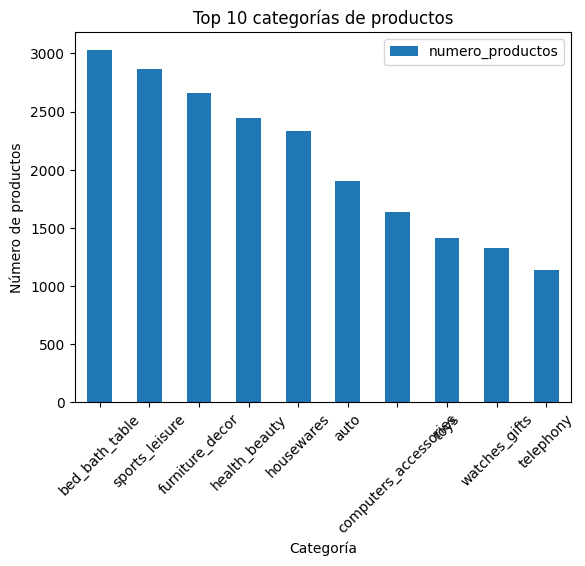

In [ ]:
# Gráfica de distribución de productos por categoría
categorias_productos.head(10).plot(
    x="product_category_name_english",
    y="numero_productos",
    kind="bar"
)

plt.title("Top 10 categorías de productos")
plt.ylabel("Número de productos")
plt.xlabel("Categoría")
plt.xticks(rotation=45)
plt.show()

El análisis de la distribución de productos por categoría evidencia que la oferta del e-commerce se concentra principalmente en categorías relacionadas con el hogar y el estilo de vida.

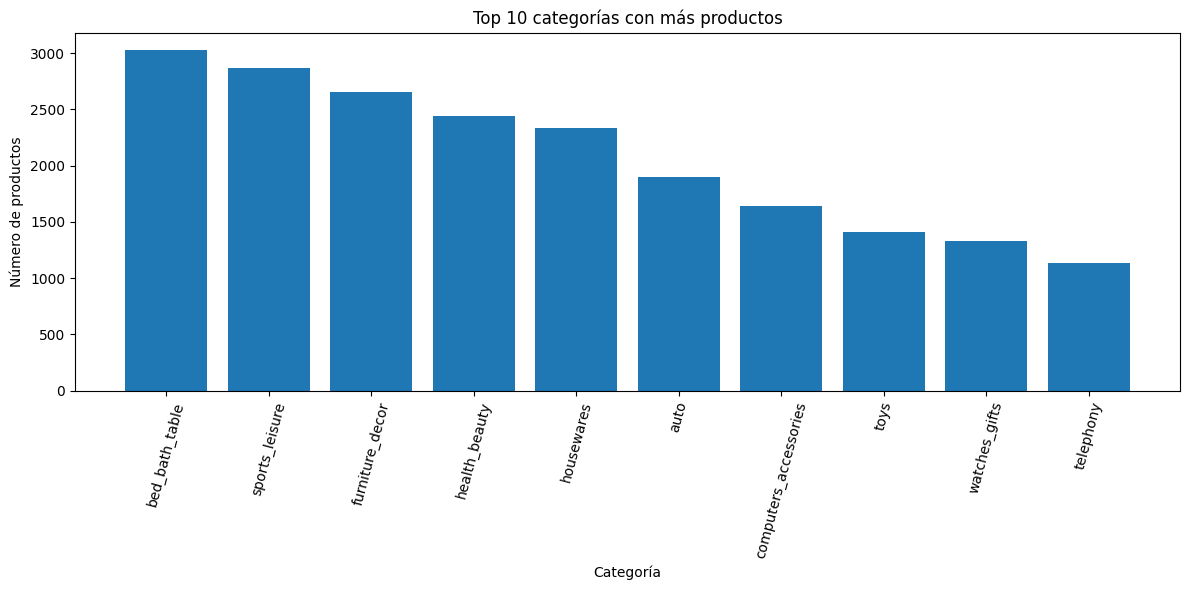

In [ ]:
# categorías con mayor número de productos
top_10_categorias = categorias_productos.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_10_categorias["product_category_name_english"], top_10_categorias["numero_productos"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías con más productos")
plt.xlabel("Categoría")
plt.ylabel("Número de productos")
plt.tight_layout()
plt.show()

El gráfico de las 10 categorías con mayor número de productos muestra que la oferta del marketplace se concentra principalmente en categorías relacionadas con el hogar, el bienestar y el estilo de vida.

La categoría bed_bath_table registra la mayor cantidad de productos, seguida de sports_leisure y furniture_decor. Esto sugiere que el catálogo tiene una fuerte orientación hacia artículos de uso doméstico, decoración y recreación.

También se evidencia la presencia de categorías tecnológicas y de consumo personal, como computers_accessories, telephony y watches_gifts, aunque con una participación menor dentro del total de productos.

In [ ]:
# Ingresos totales por categoría
ventas_categoria = order_items.merge(products, on="product_id", how="left")

ventas_categoria = (
    ventas_categoria.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["price"]
    .sum()
    .reset_index(name="ingresos_totales")
    .sort_values(by="ingresos_totales", ascending=False)
)

ventas_categoria.head(10)

,product_category_name_english,ingresos_totales
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


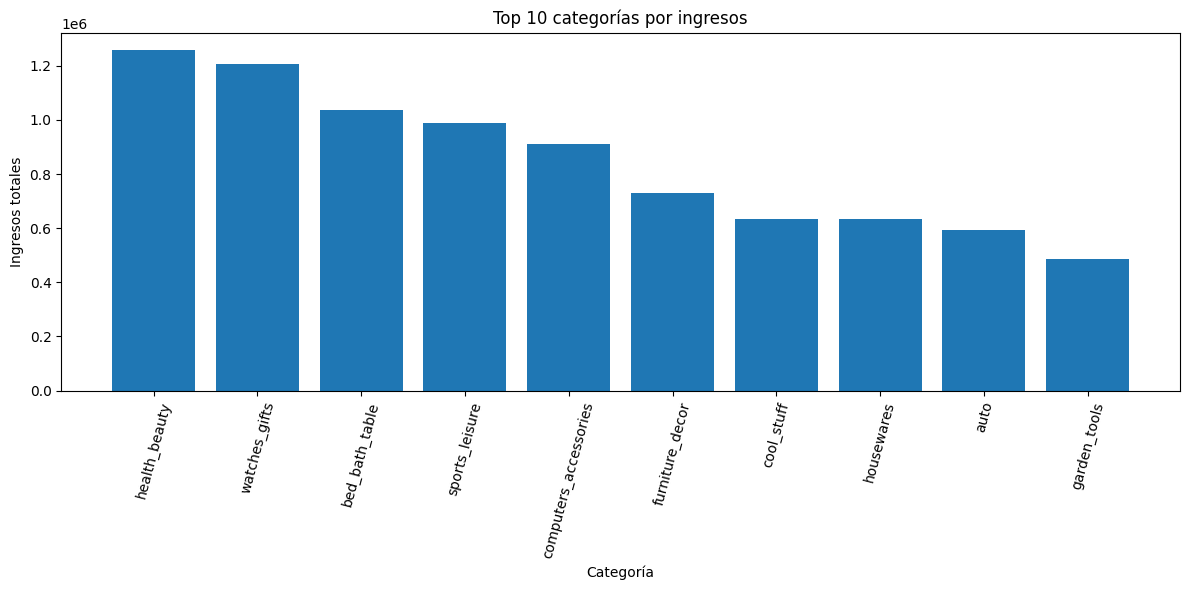

In [ ]:
# Gráfica Ingresos totales por categoría
top_ventas = ventas_categoria.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_ventas["product_category_name_english"], top_ventas["ingresos_totales"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías por ingresos")
plt.ylabel("Ingresos totales")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

El análisis de ingresos por categoría evidencia que las categorías más rentables no coinciden completamente con aquellas que tienen mayor número de productos.

La categoría health_beauty lidera en generación de ingresos, seguida de watches_gifts y bed_bath_table, lo que indica una alta demanda o mayor valor promedio por producto en estos segmentos.

Asimismo, categorías como computers_accessories muestran un alto nivel de ingresos a pesar de no estar entre las más numerosas, lo que sugiere precios unitarios más elevados o mayor rotación de productos.

In [ ]:
#tabla analítica  cruza ventas con categorías
items_con_categoria = order_items.merge(
    products[["product_id", "product_category_name", "product_category_name_english"]],
    on="product_id",
    how="left"
)

items_con_categoria.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


Se realizó la integración de la tabla de ítems de pedidos (order_items) con la información de productos (products), con el fin de incorporar la categoría de cada producto a las transacciones.

Esta unión se realizó mediante la variable product_id, utilizando un left join para conservar la totalidad de los registros de ventas.

Como resultado, se obtuvo una tabla enriquecida que permite analizar el comportamiento de ventas por categoría, incluyendo variables como precio y costo de envío.

In [ ]:
# Ticket promedio por categoría
ticket_promedio = (
    items_con_categoria
    .groupby("product_category_name_english")["price"]
    .mean()
    .reset_index(name="precio_promedio")
    .sort_values(by="precio_promedio", ascending=False)
)

ticket_promedio.head(10)

,product_category_name_english,precio_promedio
14,computers,1098.340542
64,small_appliances_home_oven_and_coffee,624.285658
45,home_appliances_2,476.124958
0,agro_industry_and_commerce,342.124858
56,musical_instruments,281.616000
63,small_appliances,280.778468
34,fixed_telephony,225.693182
19,construction_tools_safety,208.992371
70,watches_gifts,201.135984
1,air_conditioning,185.269226


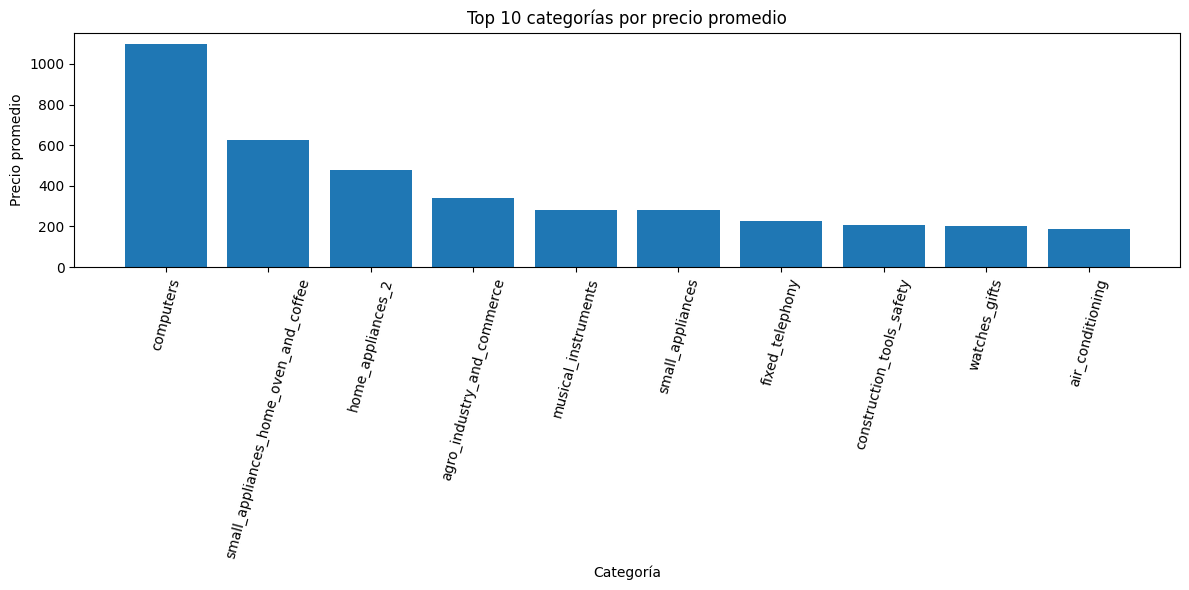

In [ ]:
# Ticket promedio por categoría
top_ticket = ticket_promedio.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_ticket["product_category_name_english"], top_ticket["precio_promedio"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías por precio promedio")
plt.ylabel("Precio promedio")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

El análisis del precio promedio por categoría permite identificar diferencias significativas en el valor de los productos comercializados.

La categoría computers presenta el mayor precio promedio, superando los 1.000 unidades monetarias, lo que indica que se trata de productos de alto valor.

De igual forma, categorías como small_appliances_home_oven_and_coffee y home_appliances_2 también presentan precios elevados, lo que sugiere que corresponden a bienes duraderos o de mayor complejidad.

En contraste, otras categorías con alta presencia en el catálogo presentan precios promedio menores, lo que refleja diferentes segmentos de mercado.

Se identifican diferentes estrategias comerciales entre categorías:

Algunas categorías generan ingresos a través de alto volumen de ventas (ej: bed_bath_table)

Otras generan ingresos mediante productos de alto valor unitario (ej: computers)

In [ ]:
# Calificación promedio por categoría
reviews_con_categoria = reviews.merge(orders, on="order_id")
reviews_con_categoria = reviews_con_categoria.merge(items_con_categoria, on="order_id")

reviews_categoria = (
    reviews_con_categoria.groupby("product_category_name_english")["review_score"]
    .mean()
    .reset_index()
    .sort_values(by="review_score", ascending=False)
)

reviews_categoria.head(10)

,product_category_name_english,review_score
11,cds_dvds_musicals,4.642857
29,fashion_childrens_clothes,4.500000
8,books_general_interest,4.446266
22,costruction_tools_tools,4.444444
35,flowers,4.419355
9,books_imported,4.400000
10,books_technical,4.368421
37,food_drink,4.315412
53,luggage_accessories,4.315257
64,small_appliances_home_oven_and_coffee,4.302632


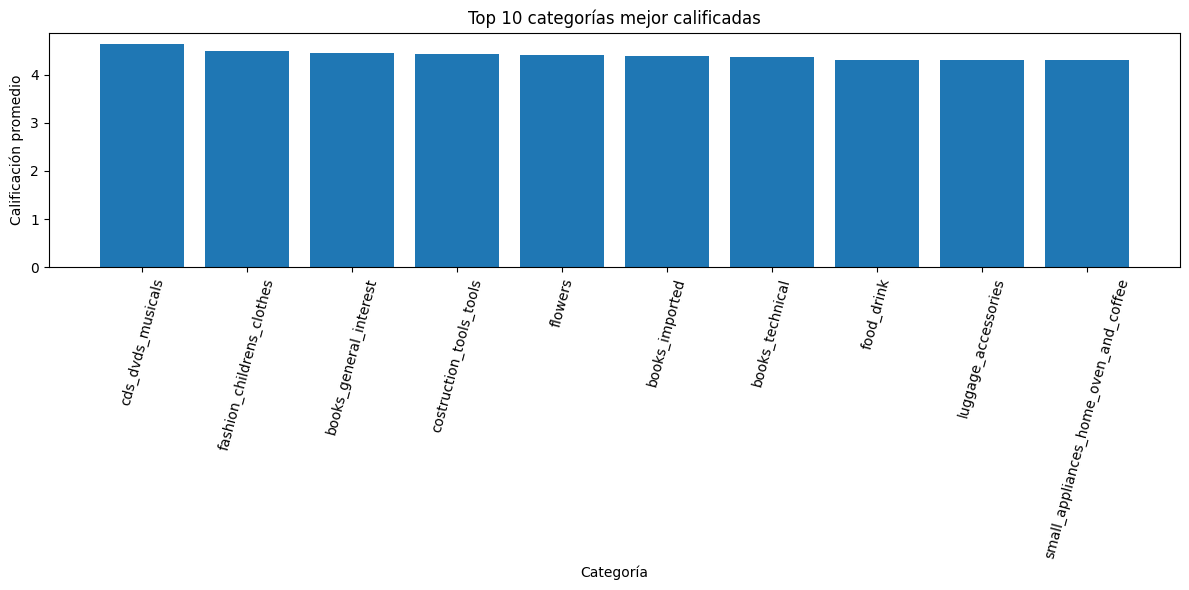

In [ ]:
# Gráfica Calificación promedio por categoría
top_reviews = reviews_categoria.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_reviews["product_category_name_english"], top_reviews["review_score"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías mejor calificadas")
plt.ylabel("Calificación promedio")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

Las categorías con mejor satisfacción NO son las que más venden

El análisis de calificaciones promedio por categoría permite identificar los segmentos con mayor nivel de satisfacción por parte de los clientes.

Se observa que categorías como cds_dvds_musicals, fashion_childrens_clothes y books_general_interest presentan las calificaciones más altas, superando valores de 4.4 sobre 5.

Esto sugiere que los productos en estas categorías cumplen adecuadamente con las expectativas del cliente, ya sea por calidad, cumplimiento en la entrega o experiencia general de compra.

Asimismo, categorías como small_appliances_home_oven_and_coffee también destacan, lo cual es relevante dado que anteriormente se identificaron como categorías de alto valor económico.

In [ ]:
# cuánto gasta un cliente en una categoría dentro de un pedido
valor_orden_categoria = (
    items_con_categoria.dropna(subset=["product_category_name_english"])
    .groupby(["product_category_name_english", "order_id"])["price"]
    .sum()
    .reset_index(name="valor_orden_categoria")
)

ticket_promedio_categoria = (
    valor_orden_categoria
    .groupby("product_category_name_english")["valor_orden_categoria"]
    .mean()
    .reset_index(name="ticket_promedio")
    .sort_values(by="ticket_promedio", ascending=False)
)

ticket_promedio_categoria["ticket_promedio"] = ticket_promedio_categoria["ticket_promedio"].round(2)
ticket_promedio_categoria.head(20)

,product_category_name_english,ticket_promedio
14,computers,1231.84
64,small_appliances_home_oven_and_coffee,632.61
45,home_appliances_2,484.26
0,agro_industry_and_commerce,398.52
56,musical_instruments,304.93
63,small_appliances,302.62
34,fixed_telephony,274.58
19,construction_tools_safety,242.78
1,air_conditioning,217.49
57,office_furniture,215.21


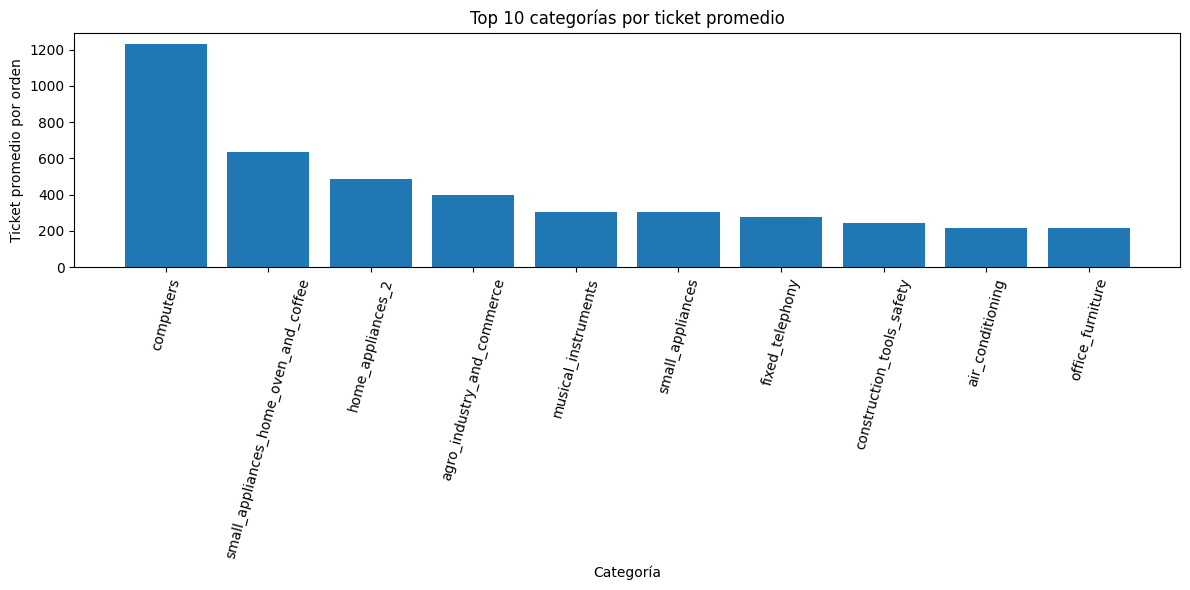

In [ ]:
# Gráfica del  gastó de un cliente en una categoría dentro de un pedido
top_ticket = ticket_promedio_categoria.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_ticket["product_category_name_english"], top_ticket["ticket_promedio"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías por ticket promedio")
plt.ylabel("Ticket promedio por orden")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

Las categorías con mayor ticket promedio representan compras de alto valor, no necesariamente frecuentes

El análisis del ticket promedio por categoría permite evaluar el valor monetario de las compras realizadas por los clientes en cada segmento.

Se observa que la categoría computers presenta el mayor ticket promedio, superando los 1.200, lo que indica que los clientes realizan compras de alto valor en este segmento.

De igual forma, categorías relacionadas con electrodomésticos y equipos especializados presentan valores elevados, lo que sugiere que estas compras suelen involucrar productos de mayor costo o múltiples artículos dentro de una misma orden.

Este análisis permite identificar categorías estratégicas que generan un alto valor por transacción, independientemente del volumen de ventas.

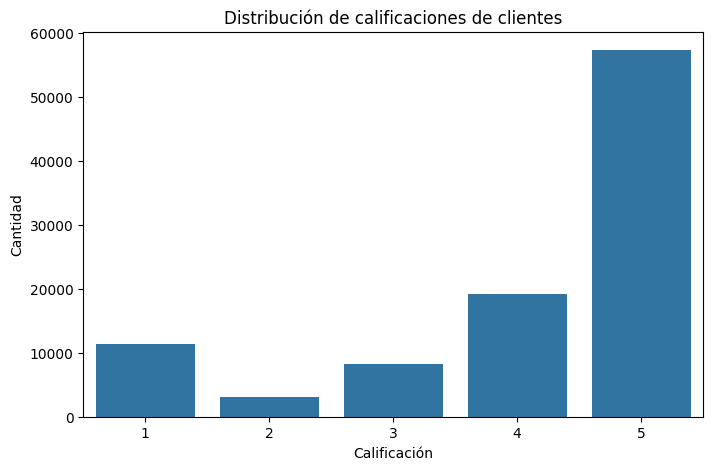

In [ ]:
# Distribución de Calificaciones
plt.figure(figsize=(8,5))
sns.countplot(x="review_score", data=reviews)
plt.title("Distribución de calificaciones de clientes")
plt.xlabel("Calificación")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
# ANÁLISIS CUANTITATIVO
reviews["review_score"].value_counts(normalize=True) * 100

review_score
5    57.776344
4    19.291704
1    11.513344
3     8.242965
2     3.175643
Name: proportion, dtype: float64

La distribución de calificaciones muestra una fuerte concentración (58%) en valores altos, especialmente en la calificación de 5 estrellas, la cual representa la mayoría de las evaluaciones realizadas por los clientes.

Las calificaciones de 4 estrellas también presentan una frecuencia significativa (19%), lo que refuerza la percepción de una experiencia de compra positiva.

En contraste, las calificaciones intermedias (2 y 3 estrellas) son menos frecuentes, mientras que las calificaciones de 1 estrella, aunque menores, representan una proporción relevante de experiencias negativas.

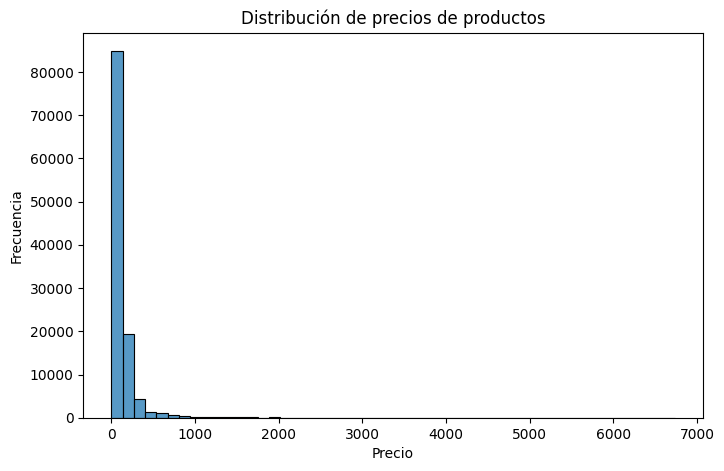

In [ ]:
# distribución económica del catálogo
plt.figure(figsize=(8,5))
sns.histplot(items_con_categoria["price"], bins=50)
plt.title("Distribución de precios de productos")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

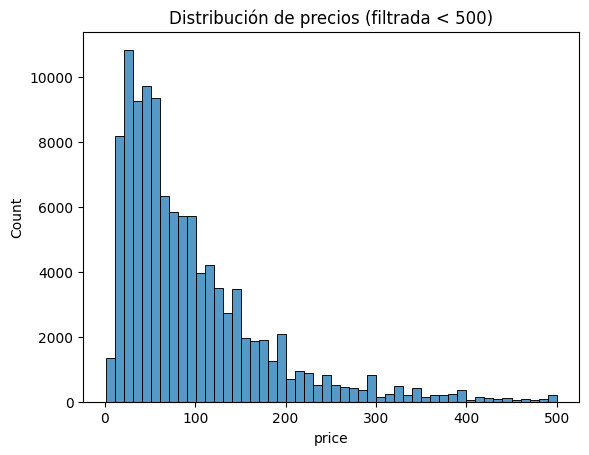

In [ ]:
# distribución económica del catálogo
sns.histplot(items_con_categoria[items_con_categoria["price"] < 500]["price"], bins=50)
plt.title("Distribución de precios (filtrada < 500)")
plt.show()

La mayoría de los productos pertenecen a un segmento de bajo costo.

El marketplace está dominado por productos de bajo costo, con una minoría de productos premium

La distribución de precios presenta una fuerte asimetría positiva, donde la mayoría de los productos se concentran en rangos de precios bajos, mientras que un pequeño número de productos alcanza valores significativamente altos.

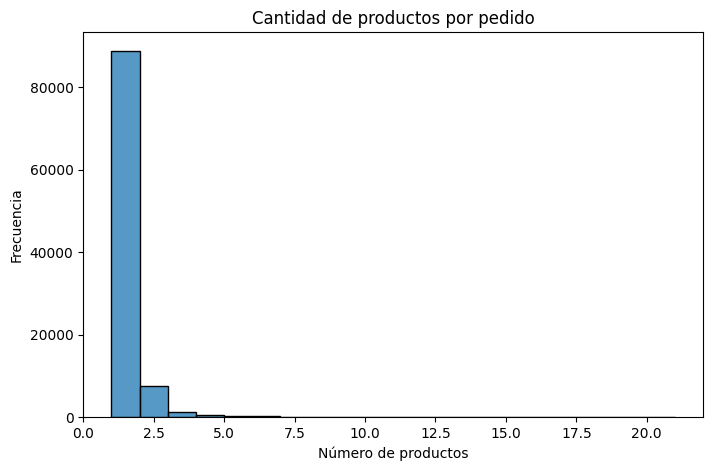

In [ ]:
# histograma de cantidad de productos por pedido
productos_por_orden = order_items.groupby("order_id")["order_item_id"].count()

plt.figure(figsize=(8,5))
sns.histplot(productos_por_orden, bins=20)
plt.title("Cantidad de productos por pedido")
plt.xlabel("Número de productos")
plt.ylabel("Frecuencia")
plt.show()

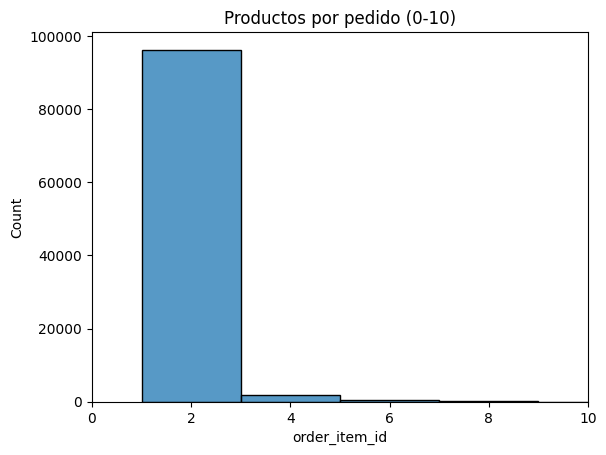

In [ ]:
# # histograma de cantidad de productos por pedido
sns.histplot(productos_por_orden, bins=10)
plt.xlim(0,10)
plt.title("Productos por pedido (0-10)")
plt.show()

Los clientes compran principalmente un solo producto por pedido

La distribución de la cantidad de productos por pedido muestra que la mayoría de las órdenes contienen un solo producto, lo que indica un comportamiento de compra simple y directo por parte de los clientes.

Un menor porcentaje de pedidos incluye dos o más productos, mientras que los pedidos con una alta cantidad de artículos son poco frecuentes.

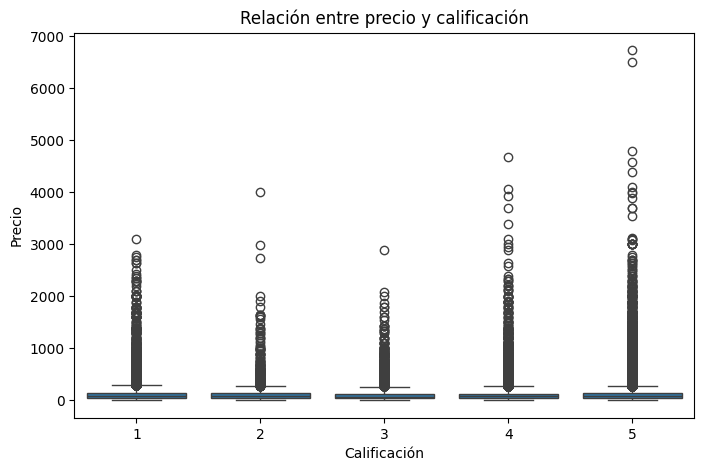

In [38]:
# precio vs satisfacción
reviews_items = reviews.merge(items_con_categoria, on="order_id")

plt.figure(figsize=(8,5))
sns.boxplot(x="review_score", y="price", data=reviews_items)
plt.title("Relación entre precio y calificación")
plt.xlabel("Calificación")
plt.ylabel("Precio")
plt.show()

El precio no determina la satisfacción del cliente

El análisis de la relación entre el precio del producto y la calificación del cliente muestra que no existe una correlación clara entre estas variables.

Las distribuciones de precios son similares en todos los niveles de calificación, lo que indica que productos más costosos no necesariamente reciben mejores valoraciones.

Asimismo, se observa una alta dispersión de precios en todas las categorías de calificación, incluyendo valores atípicos en productos con puntuaciones tanto bajas como altas.

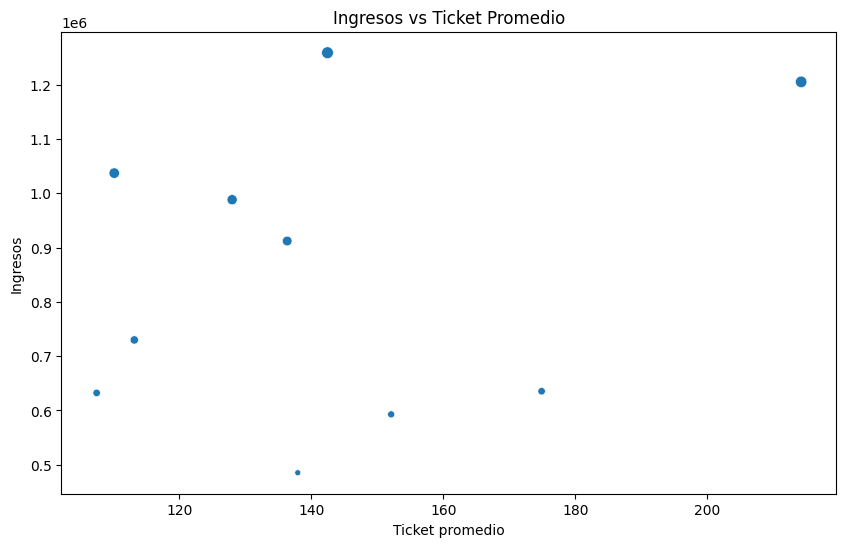

In [ ]:
# relación entre el ticket promedio y los ingresos totales
comparacion = ventas_categoria.merge(ticket_promedio_categoria, on="product_category_name_english")

top_comp = comparacion.head(10)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=top_comp,
    x="ticket_promedio",
    y="ingresos_totales",
    size="ingresos_totales",
    legend=False
)

plt.title("Ingresos vs Ticket Promedio")
plt.xlabel("Ticket promedio")
plt.ylabel("Ingresos")
plt.show()

NO existe una relación directa entre estas variables.

Los ingresos dependen de un balance entre volumen y valor, no solo del ticket promedio

Algunas categorías con ticket promedio elevado no necesariamente generan los mayores ingresos, mientras que otras con valores intermedios presentan un alto volumen de ingresos.

Esto sugiere que los ingresos dependen tanto del valor de cada compra como del volumen de ventas, reflejando diferentes dinámicas comerciales dentro del marketplace.

## **Cierre** ##  

El análisis exploratorio de datos permitió comprender de manera integral la estructura, calidad y dinámica del dataset de comercio electrónico, evidenciando un sistema robusto compuesto por múltiples tablas interrelacionadas que describen el comportamiento de clientes, productos, pedidos, pagos y reseñas. Se identificó una alta calidad de la información, caracterizada por la ausencia de duplicados en las claves principales y una baja proporción de valores nulos, lo cual garantiza la confiabilidad de los resultados obtenidos y permite avanzar hacia etapas de modelado sin limitaciones significativas.

En términos de comportamiento de compra, **uno de los hallazgos más relevantes fue que la mayoría de los pedidos contienen un solo producto**, lo que evidencia una baja presencia de compras múltiples dentro de una misma transacción. Este patrón sugiere que actualmente la plataforma no está aprovechando de manera eficiente las oportunidades de venta cruzada, lo cual se alinea directamente con el problema de negocio planteado. La ausencia de mecanismos que incentiven la adquisición de productos complementarios limita el crecimiento del valor promedio por pedido.

Adicionalmente, el análisis por categorías permitió identificar una distribución desigual tanto en volumen de productos como en generación de ingresos. Categorías como bed_bath_table, sports_leisure y furniture_decor concentran una alta cantidad de productos, mientras que otras como health_beauty y watches_gifts destacan por su mayor contribución en ingresos. **Este comportamiento evidencia que el tamaño del catálogo no es el único factor determinante del desempeño económico, sino que intervienen variables como el precio, la demanda y la frecuencia de compra**.

En relación con el valor económico, se identificaron diferencias significativas en el ticket promedio entre categorías. Algunas, como computers y home_appliances, presentan tickets elevados, mientras que otras tienen un enfoque más orientado al volumen con precios más bajos. **Este hallazgo es clave para el desarrollo del proyecto, ya que permite utilizar el ticket promedio como un criterio estratégico para priorizar recomendaciones que contribuyan al incremento del valor de las compras**.

El análisis de precios mostró una distribución altamente sesgada hacia valores bajos, con una concentración significativa de productos económicos y una menor proporción de productos de alto costo. Por su parte, la evaluación de las calificaciones de los clientes evidenció un alto nivel de satisfacción general, con predominio de valoraciones de 4 y 5 estrellas, lo cual indica una experiencia positiva en la mayoría de las transacciones, aunque también se identifican oportunidades de mejora en casos con calificaciones bajas.

Un hallazgo clave fue la ausencia de una relación directa entre el precio de los productos y la calificación otorgada por los clientes, así como entre el ticket promedio y los ingresos totales por categoría. **Esto demuestra que el comportamiento del mercado es multifactorial y que variables como la percepción de valor, la utilidad del producto y la experiencia de compra juegan un papel fundamental en la toma de decisiones del consumidor**.

En conjunto, los resultados del EDA evidencian la existencia de diferentes dinámicas de consumo dentro del marketplace, donde coexisten categorías orientadas al volumen y otras orientadas al valor. **Esta dualidad representa una oportunidad estratégica para diseñar un sistema de recomendación que no solo sugiera productos relevantes, sino que también promueva la complementariedad entre categorías, incentivando la compra de múltiples productos dentro de una misma transacción**.

Finalmente, los hallazgos obtenidos permiten validar el problema de negocio planteado, evidenciando que la plataforma actualmente no cuenta con mecanismos que exploten las relaciones entre categorías ni que utilicen el ticket promedio como criterio de recomendación. En este contexto, el siguiente paso del proyecto se enfocará en el desarrollo de un sistema de recomendación orientado a la venta cruzada, basado en la agrupación de categorías relacionadas y en la priorización de productos que contribuyan al aumento del valor de compra por cliente, en coherencia con el objetivo general definido.


